<a href="https://colab.research.google.com/github/beaconfident/FMML/blob/main/Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Foundation of Modern Machine Learning
## Module 9: Neural Networks
## Lab 2: Using MLP for multiclass classification
#### Module Coordinator: Shantanu Agrawal




Till now, we got to know what is MLP, how it can be used for classification. We have done the single class classification in the previous lab session.

In this notebook we will try to use an MLP for multiclass classification on the iris dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data preparation

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the iris dataset
iris = load_iris()
X = iris['data']
y = iris['target']
names = iris['target_names']
feature_names = iris['feature_names']

# Scale data to have mean 0 and variance 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data set into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=2)

# Visualising dataset

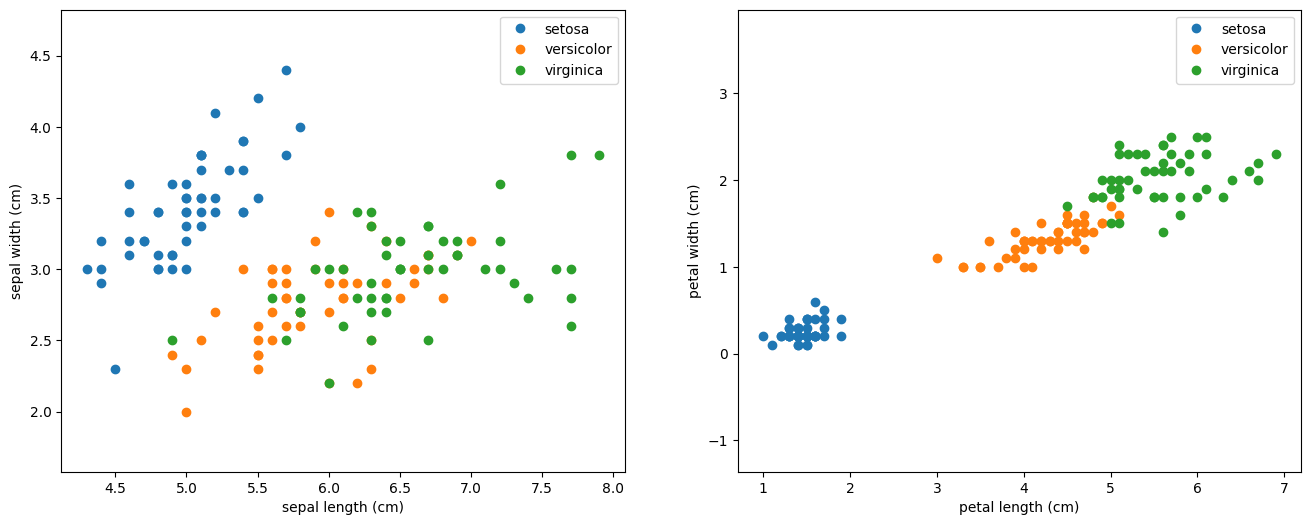

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for target, target_name in enumerate(names):
    X_plot = X[y == target]
    ax1.plot(X_plot[:, 0], X_plot[:, 1],
             linestyle='none',
             marker='o',
             label=target_name)
ax1.set_xlabel(feature_names[0])
ax1.set_ylabel(feature_names[1])
ax1.axis('equal')
ax1.legend();

for target, target_name in enumerate(names):
    X_plot = X[y == target]
    ax2.plot(X_plot[:, 2], X_plot[:, 3],
             linestyle='none',
             marker='o',
             label=target_name)
ax2.set_xlabel(feature_names[2])
ax2.set_ylabel(feature_names[3])
ax2.axis('equal')
ax2.legend();


# Observing the dataset

Thus, we can observe the dataset and see that there are *3 classes, setosa, versicolor, and virginica*.

There are *4 features, sepal width, sepal length, petal width, petal length*.

# MLP for multiclass classification

In [4]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.autograd import Variable
import tqdm

In [5]:
# Defining the model architecture
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.layer1 = nn.Linear(input_dim, 50)
        self.layer2 = nn.Linear(50, 50)
        self.layer3 = nn.Linear(50, 3)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.softmax(self.layer3(x), dim=1)
        return x

In [6]:
# Instantiating the model, using Adam optimiser, and Cross Entropy Loss, which is quite commonlu used for classification tasks.
model     = Model(X_train.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn   = nn.CrossEntropyLoss()

# Train the model

In [7]:
# Train for 100 epochs
EPOCHS  = 100
X_train = torch.from_numpy(X_train).float()
X_test= torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test)
y_train = torch.from_numpy(y_train)


loss_list     = np.zeros((EPOCHS,))
accuracy_list = np.zeros((EPOCHS,))

for epoch in tqdm.trange(EPOCHS):
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    loss_list[epoch] = loss.item()

    # Zero gradients
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        y_pred = model(X_test)
        correct = (torch.argmax(y_pred, dim=1) == y_test).type(torch.FloatTensor)
        accuracy_list[epoch] = correct.mean()

100%|██████████| 100/100 [00:00<00:00, 365.38it/s]


# Plot training progress

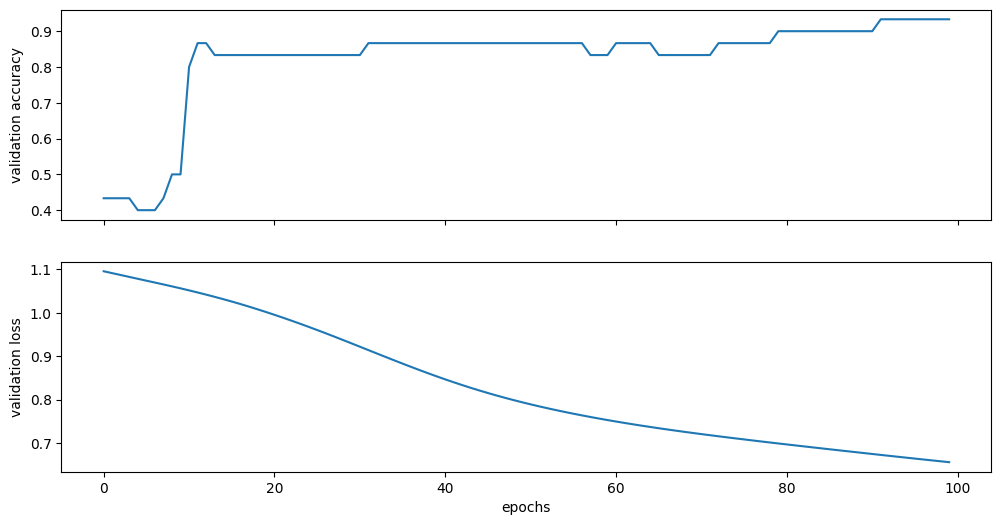

In [8]:
fig, (ax1, ax2) = plt.subplots(2, figsize=(12, 6), sharex=True)

ax1.plot(accuracy_list)
ax1.set_ylabel("validation accuracy")
ax2.plot(loss_list)
ax2.set_ylabel("validation loss")
ax2.set_xlabel("epochs");

# Experiment with the neural network architecture


1.   Try changing the number of hidden layers.
💡 What happens when you change the number of hidden layers?
0 Hidden Layers:

This is essentially a single-layer perceptron (SLP).

Can only solve linearly separable problems (like AND, OR).

Will fail on XOR or any nonlinear decision boundary.

1 Hidden Layer:

Can solve any problem, including XOR, as long as it has enough neurons.

This is the "universal approximator" setup.

2 or more Hidden Layers:

Better for modeling complex patterns.

May improve performance on more complicated datasets, but for simple logic gates, it's overkill.

Risk of overfitting on small datasets like XOR or AND.

✅ Observation:
For logic gates, 1 hidden layer is usually sufficient.

More layers increase training time and complexity with minimal benefit for simple tasks.
2.   Try changing the number of neurons in the hidden layer.
💡 What happens?
Too Few Neurons:

Model might be underpowered — can't learn the pattern well.

E.g., XOR with 1 neuron might not converge at all.

Optimal Neurons:

E.g., XOR is perfectly solved with 2 neurons in 1 hidden layer.

AND/OR only need 1 neuron in most cases.

Too Many Neurons:

May lead to overfitting, especially with small datasets.

Training becomes slower, and results may not generalize well.

✅ Observation:
Increasing neurons improves learning up to a point.

Too many neurons = risk of memorization (overfitting).
3.   Try using a different activation function.
💡 Common Activation Functions and Their Behavior:
Activation	Output Range	Characteristics	Good for
sigmoid	0 to 1	Smooth but can saturate	Binary outputs
tanh	-1 to 1	Zero-centered, better than sigmoid	Bipolar inputs/outputs
ReLU	0 to ∞	Fast, sparse, avoids vanishing gradient	Deep networks
leaky ReLU	Slightly negative for x < 0	Fixes dead neuron problem	Robust training
identity	Linear	No non-linearity	Just a linear model (bad for XOR etc.)
✅ Observation:
XOR with sigmoid or tanh: Works well.

ReLU: Might need more tuning for logic gates but trains faster.

No activation: Fails on XOR (same as removing non-linearity).

Wrong activation (e.g., identity): Model behaves like a linear classifier.






Can you observe any changes?
🔍 Summary of Observations:
Change	Expected Result
Fewer layers or no hidden layer	Can't learn non-linear patterns
One hidden layer with enough neurons	Can solve XOR and similar
Too many layers/neurons	Overfitting, slower training
Different activations	Affects learning quality and output behavior
No activation	Model can't learn non-linearity
